In [ ]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import h5py
import halo_analysis as halo
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"


scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

snap = 600

In [26]:
all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])

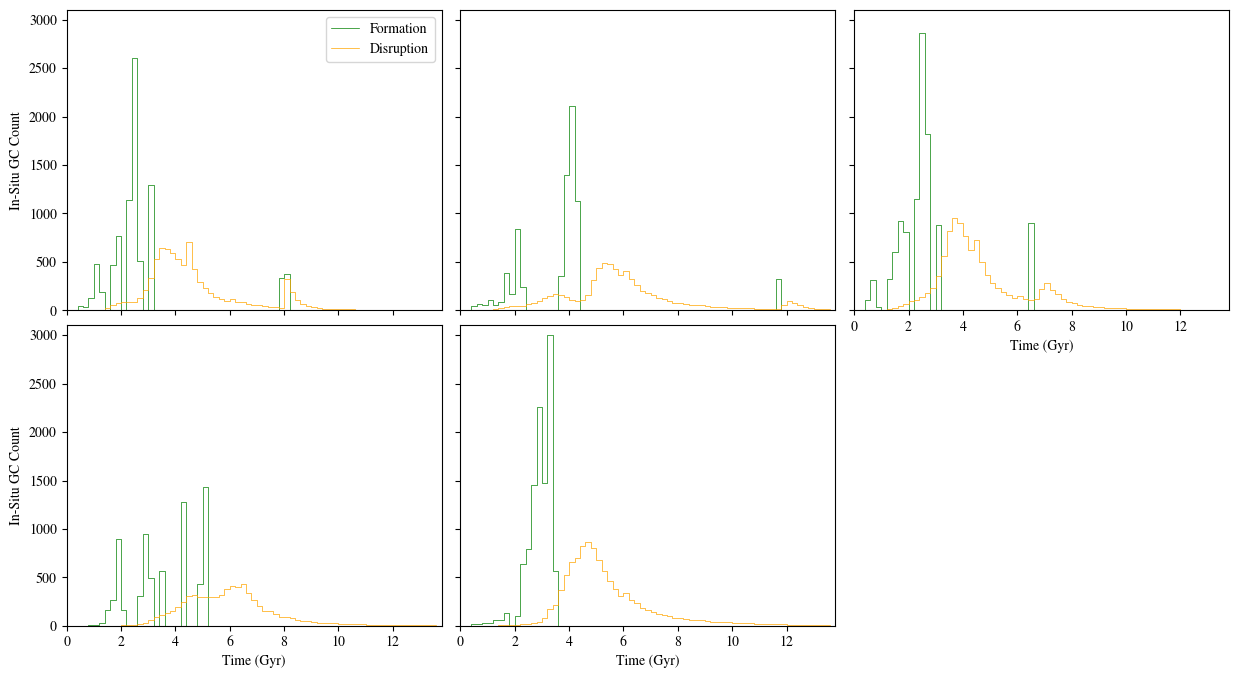

In [3]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i, ax in enumerate(axs.flatten()):
    if i == 5:
        ax.axis("off")
        continue

    sim = sim_lst[i]
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    hist_dict = {"sum_for": None, "sum_dis": None, "n": 0}
    bins = np.arange(0, 14, 0.2)

    all_tfors = []
    all_tdiss = []
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]
        insitu_msk = src_dat["grpid"][()] == 0
        tfors = src_dat["tfor"][insitu_msk]
        tdiss = src_dat["tdis"][insitu_msk]
        all_tfors.append(tfors)
        all_tdiss.append(tdiss)

        hssp_for, _ = np.histogram(tfors, bins=bins)
        hssp_dis, _ = np.histogram(tdiss, bins=bins)

        if hist_dict["sum_for"] is None:
            hist_dict["sum_for"] = hssp_for.astype(float)
            hist_dict["sum_dis"] = hssp_dis.astype(float)
        else:
            hist_dict["sum_for"] += hssp_for
            hist_dict["sum_dis"] += hssp_dis
        hist_dict["n"] += 1

    binsum_for = hist_dict["sum_for"] / hist_dict["n"]
    binsum_dis = hist_dict["sum_dis"] / hist_dict["n"]
    ax.step(bins[:-1], binsum_for, where="post", color="g", lw=0.5, label="Formation")
    ax.step(bins[:-1], binsum_dis, where="post", color="orange", lw=0.5, label="Disruption")

    if i == 0:
        ax.legend(loc="upper right")

    ax.set_xlim(0, 13.8)
    ax.set_ylim(0, 3100)

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")

    if i in [0, 1]:
        ax.set_xticklabels([])

    if i in [0, 3]:
        ax.set_ylabel("In-Situ GC Count")

    if i in [1, 2, 4]:
        ax.set_yticklabels([])

In [14]:
sim = "m12i"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"
data_directory = sim_dir + sim + "/" + sim + "_res7100/"

In [ ]:
halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:41<00:00, 41.87s/it]


In [9]:
hal600 = halo.io.IO.read_catalogs("index", 600, data_directory, species="star")

In [15]:
part600 = gc_utils.open_snapshot(600, fire_dir, species="star")

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.63s/it]


(array([0.003994  , 0.02019912, 0.06343877, 0.09798642, 0.11260612,
        0.14040629, 0.10672748, 0.08159731, 0.06613944, 0.04600776]),
 array([ 0.26879714,  1.62178904,  2.97478095,  4.32777285,  5.68076475,
         7.03375665,  8.38674856,  9.73974046, 11.09273236, 12.44572426,
        13.79871617]),
 <BarContainer object of 10 artists>)

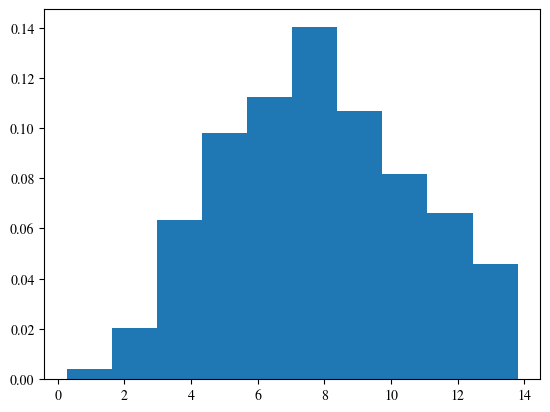

In [30]:
msk = part600["star"].prop("host.principal.distance.total") < 10
ages = part600["star"].prop("age")[msk]

tfors = all_times[600] - ages

plt.hist(tfors, density=True)

# one place

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:21<00:00, 21.15s/it]


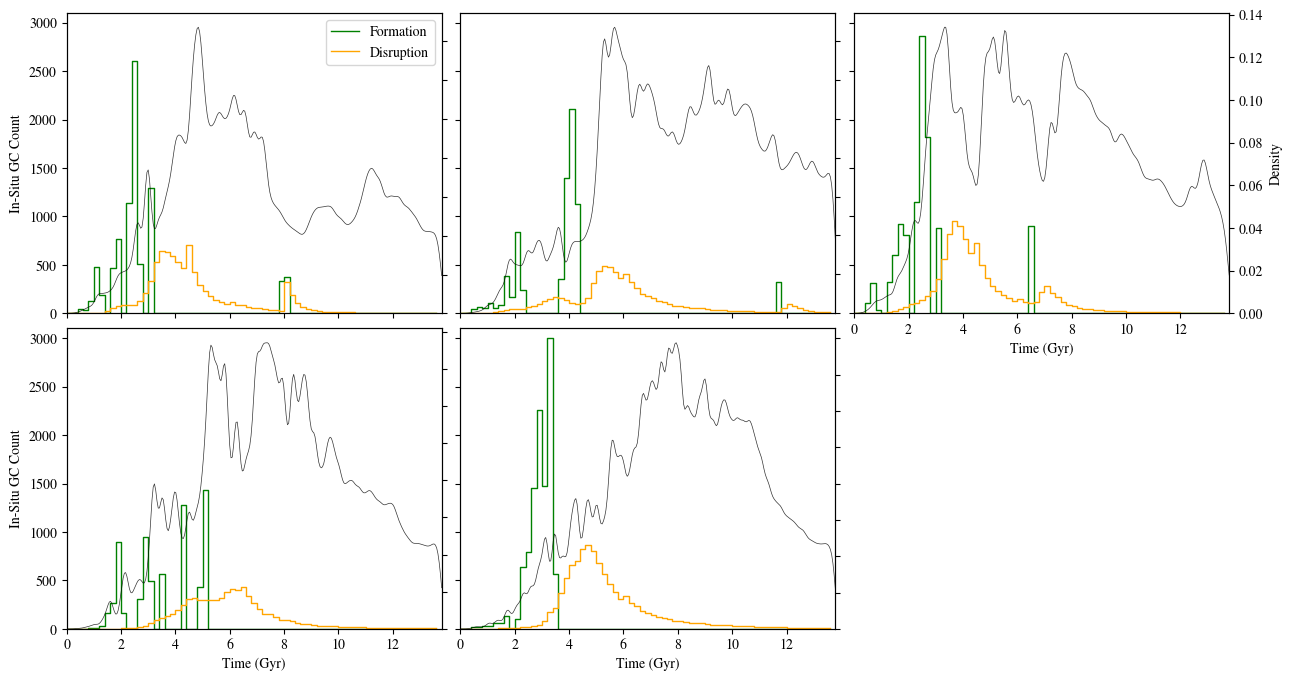

In [ ]:
# ------------------ SETUP ------------------
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

snap = 600
r_lim = 10  # kpc

# snapshot times (use m12i, same clock for all FIRE sims)
all_data_fil = f"{sim_dir}/m12i/m12i_res7100/snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = ["index", "scale_factor", "redshift", "time_Gyr", "lookback_time_Gyr", "time_width_Myr"]
all_times = np.array(all_data["time_Gyr"])

# ------------------ PRELOAD STAR TFOR ------------------
star_tfor_dict = {}

for sim in sim_lst:
    fire_dir = f"{sim_dir}{sim}/{sim}_res7100"
    part = gc_utils.open_snapshot(snap, fire_dir, species="star")

    msk = part["star"].prop("host.principal.distance.total") < r_lim
    # ages = part["star"].prop("age")[msk]

    star_tfor_dict = part["star"].prop("form.time")[msk]

    # star_tfor_dict[sim] = all_times[snap] - ages

# ------------------ FIGURE ------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

bins = np.arange(0, 14, 0.2)

for i, ax in enumerate(axs.flatten()):
    if i == 5:
        ax.axis("off")
        continue

    sim = sim_lst[i]

    # ---------- GC DATA ----------
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    hist_for = np.zeros(len(bins) - 1)
    hist_dis = np.zeros(len(bins) - 1)
    n = 0

    for it_id in ghost_data.keys():
        src = ghost_data[it_id]["source"]
        m = src["grpid"][()] == 0

        tfors = src["tfor"][m]
        tdiss = src["tdis"][m]

        h_for, _ = np.histogram(tfors, bins=bins)
        h_dis, _ = np.histogram(tdiss, bins=bins)

        hist_for += h_for
        hist_dis += h_dis
        n += 1

    hist_for /= n
    hist_dis /= n

    ax.step(bins[:-1], hist_for, where="post", color="g", lw=1, label="Formation")
    ax.step(bins[:-1], hist_dis, where="post", color="orange", lw=1, label="Disruption")

    # ---------- STELLAR KDE ----------
    tfors_star = star_tfor_dict[sim]

    ax2 = ax.twinx()

    if len(tfors_star) > 10:
        kde = gaussian_kde(tfors_star)
        x = np.linspace(0, 13.8, 300)
        y = kde(x)

        # optional scaling so it's visible vs counts
        # y *= 1000

        ax2.plot(x, y, color="k", lw=0.5, alpha=0.8)

    # ---------- FORMATTING ----------
    ax.set_xlim(0, 13.8)
    ax.set_ylim(0, 3100)
    ax2.set_ylim(0, None)

    if i == 0:
        ax.legend(loc="upper right")

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")
    else:
        ax.set_xticklabels([])

    if i in [0, 3]:
        ax.set_ylabel("In-Situ GC Count")
    else:
        ax.set_yticklabels([])

    # only right column gets density label
    if i in [2, 5]:
        ax2.set_ylabel("Density")
    else:
        ax2.set_yticklabels([])

plt.show()

Retrieving Snapshot 600..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:21<00:00, 21.35s/it]


Text(0, 0.5, 'V$_{\\phi}$ [km/s]')

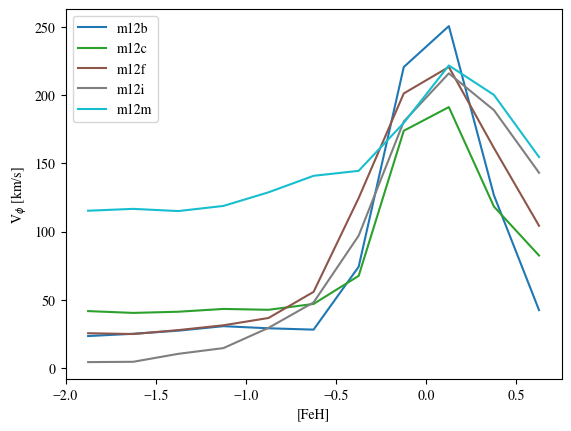

In [69]:
for sim in sim_lst:
    fire_dir = f"{sim_dir}{sim}/{sim}_res7100"
    part = gc_utils.open_snapshot(snap, fire_dir, species="star")

    msk = part["star"].prop("host.distance.principal.total") < 10
    feh = part["star"].prop("metallicity.fe")[msk]
    vphi = part["star"].prop("host.velocity.principal.cylindrical")[msk][:, 1]

    bins = np.arange(-2, 1, 0.25)

    bin_idx = np.digitize(feh, bins)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    vphi_r = np.full(len(bin_centers), np.nan)

    for i in range(1, len(bins)):
        mask = bin_idx == i
        if np.any(mask):
            vphi_r[i - 1] = np.median(vphi[mask])

    plt.plot(bin_centers, vphi_r, c=sim_colors[sim], label=sim)
plt.legend()

plt.xlabel("[FeH]")
plt.ylabel(r"V$_{\phi}$ [km/s]")